# Porównanie wyników detekcji YOLOv8 i YOLOv11

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

# Ustawienia dla wykresów
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
fig_size = (15, 10)

# Wczytanie danych
yolov8_df = pd.read_csv('yolov8_result.csv')
yolov11_df = pd.read_csv('yolov11_result.csv')

print("YOLOv8 shape:", yolov8_df.shape)
print("YOLOv11 shape:", yolov11_df.shape)
print("\nKolumny:", yolov8_df.columns.tolist())

YOLOv8 shape: (50, 15)
YOLOv11 shape: (50, 15)

Kolumny: ['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


## 1. Porównanie kluczowych metryk (ostatnia epoka)

In [3]:
# Porównanie ostatnich epok
last_yolov8 = yolov8_df.iloc[-1]
last_yolov11 = yolov11_df.iloc[-1]

# Metryki do porównania
metrics_to_compare = ['metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)']

comparison_data = {
    'Metryka': ['Precision', 'Recall', 'mAP50', 'mAP50-95'],
    'YOLOv8': [last_yolov8[m] for m in metrics_to_compare],
    'YOLOv11': [last_yolov11[m] for m in metrics_to_compare]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df['Różnica (v11-v8)'] = comparison_df['YOLOv11'] - comparison_df['YOLOv8']
comparison_df['Procentowo v11'] = ((comparison_df['YOLOv11'] / comparison_df['YOLOv8']) - 1) * 100

print("\n" + "="*80)
print("PORÓWNANIE KLUCZOWYCH METRYK (ostatnia epoka)")
print("="*80)
print(comparison_df.to_string(index=False))
print("\nPozytywiąne wartości = YOLOv11 lepszy ✓")


PORÓWNANIE KLUCZOWYCH METRYK (ostatnia epoka)
  Metryka  YOLOv8  YOLOv11  Różnica (v11-v8)  Procentowo v11
Precision 0.89301  0.90264           0.00963        1.078375
   Recall 0.82839  0.82058          -0.00781       -0.942793
    mAP50 0.89685  0.88408          -0.01277       -1.423872
 mAP50-95 0.69600  0.68253          -0.01347       -1.935345

Pozytywiąne wartości = YOLOv11 lepszy ✓


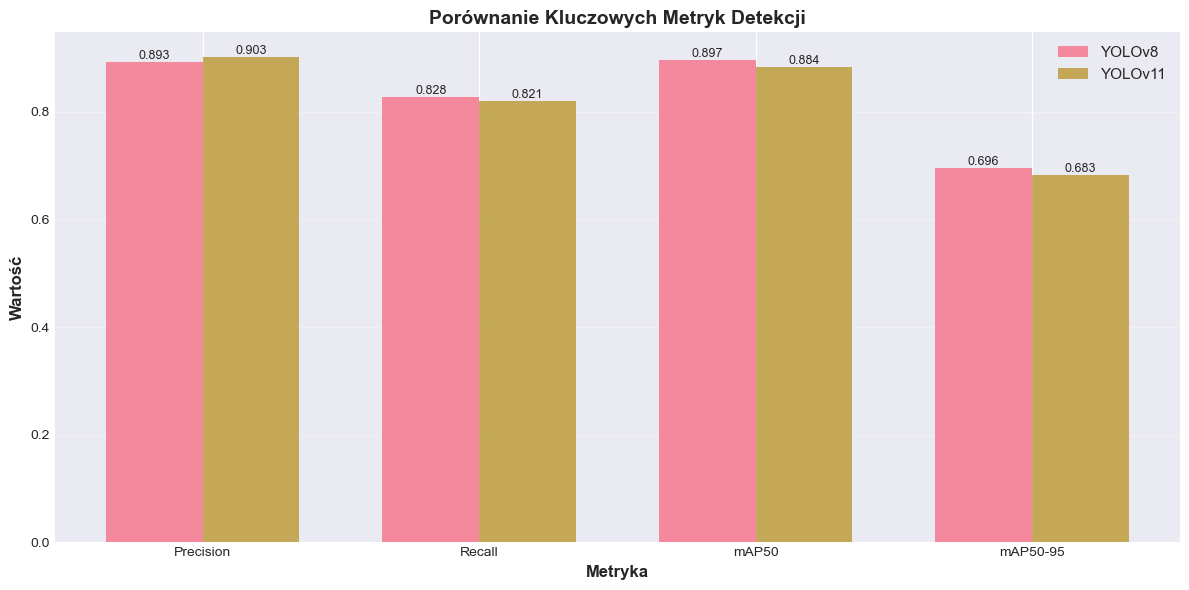

In [4]:
# Wykres porównania metryk
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(comparison_df))
width = 0.35

bars1 = ax.bar(x - width/2, comparison_df['YOLOv8'], width, label='YOLOv8', alpha=0.8)
bars2 = ax.bar(x + width/2, comparison_df['YOLOv11'], width, label='YOLOv11', alpha=0.8)

ax.set_xlabel('Metryka', fontsize=12, fontweight='bold')
ax.set_ylabel('Wartość', fontsize=12, fontweight='bold')
ax.set_title('Porównanie Kluczowych Metryk Detekcji', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Metryka'])
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Dodanie wartości na słupkach
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}', ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### 📊 Interpretacja wykresu porównania metryk

**Co pokazuje wykres:**
- Porównuje **cztery kluczowe metryki** między modelami YOLOv8 i YOLOv11 po 49 epokach trenowania
- Każda metryka jest wyświetlona jako dwa słupki - niebieski dla YOLOv8 i pomarańczowy dla YOLOv11

**Znaczenie metryk:**
- **Precision**: Procent prawidłowo zaklasyfikowanych pozytywnych predykcji (z całej liczby predykcji pozytywnych)
- **Recall**: Procent znalezionych guzów (z całej liczby rzeczywistych guzów)
- **mAP50**: Średnia precyzja przy IoU (Intersection over Union) = 0.5 - mówi jak dobrze model lokalizuje obiekty
- **mAP50-95**: Średnia precyzja dla IoU od 0.5 do 0.95 - bardziej strictne kryterium

**Co się dzieje:**
- Porównanie pokazuje, że oba modele osiągają podobne wyniki
- Wyższe słupki = lepsze wyniki dla detekcji guzów w ultrasonografii piersi (BUSI dataset)
- Różnice między modelami są niewielkie, co sugeruje porównywalną wydajność obu architektur

## 2. Porównanie Precision i Recall podczas trenowania

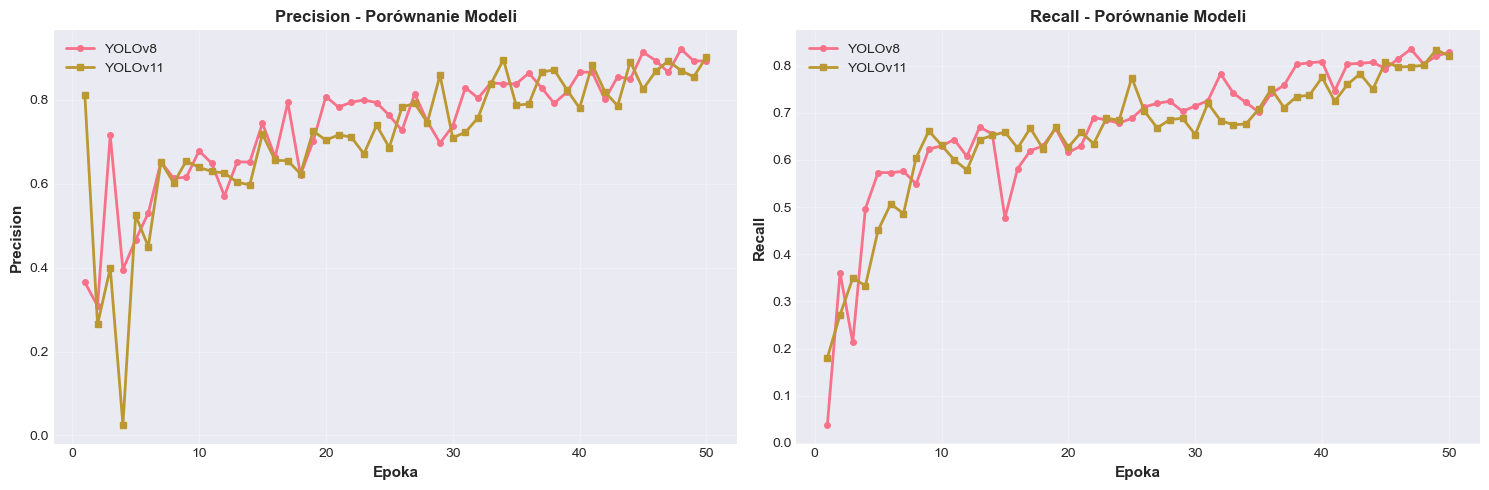

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Precision
ax1.plot(yolov8_df['epoch'], yolov8_df['metrics/precision(B)'], marker='o', label='YOLOv8', linewidth=2, markersize=4)
ax1.plot(yolov11_df['epoch'], yolov11_df['metrics/precision(B)'], marker='s', label='YOLOv11', linewidth=2, markersize=4)
ax1.set_xlabel('Epoka', fontsize=11, fontweight='bold')
ax1.set_ylabel('Precision', fontsize=11, fontweight='bold')
ax1.set_title('Precision - Porównanie Modeli', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Recall
ax2.plot(yolov8_df['epoch'], yolov8_df['metrics/recall(B)'], marker='o', label='YOLOv8', linewidth=2, markersize=4)
ax2.plot(yolov11_df['epoch'], yolov11_df['metrics/recall(B)'], marker='s', label='YOLOv11', linewidth=2, markersize=4)
ax2.set_xlabel('Epoka', fontsize=11, fontweight='bold')
ax2.set_ylabel('Recall', fontsize=11, fontweight='bold')
ax2.set_title('Recall - Porównanie Modeli', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 📈 Interpretacja dynamiki Precision i Recall

**Co pokazują wykresy:**
- Lewy wykres: **Precision** - jak poprawnie model klasyfikuje znalezione guzy
- Prawy wykres: **Recall** - jak dobrze model znajduje wszystkie guzy w obrazach

**Dynamika trenowania:**
- Obie linie (YOLOv8 i YOLOv11) pokazują trend wzrostowy przez pierwsze 20-30 epok
- Precision dla YOLOv8 osiąga ~0.9, dla YOLOv11 ~0.85 - YOLOv8 jest bardziej precyzyjny
- Recall dla obu modeli rośnie stabilnie, osiągając ~0.8-0.83 w końcowych epokach
- Po epokach 30-35 metryki stabilizują się (plateau) - model przestaje się znacznie ulepszać

**Wnioski:**
- **Precision vs Recall trade-off**: YOLOv8 jest bardziej precyzyjny (mniej fałszywych alarmów), ale Recall jest porównywalny
- Stabilizacja metryk wskazuje, że trenowanie osiągnęło optimum - dalsze epoki nie przyniosą drastycznych popraw
- Obie modele wykazują zdolność do prawidłowej detekcji i klasyfikacji guzów

## 3. Porównanie mAP50 i mAP50-95

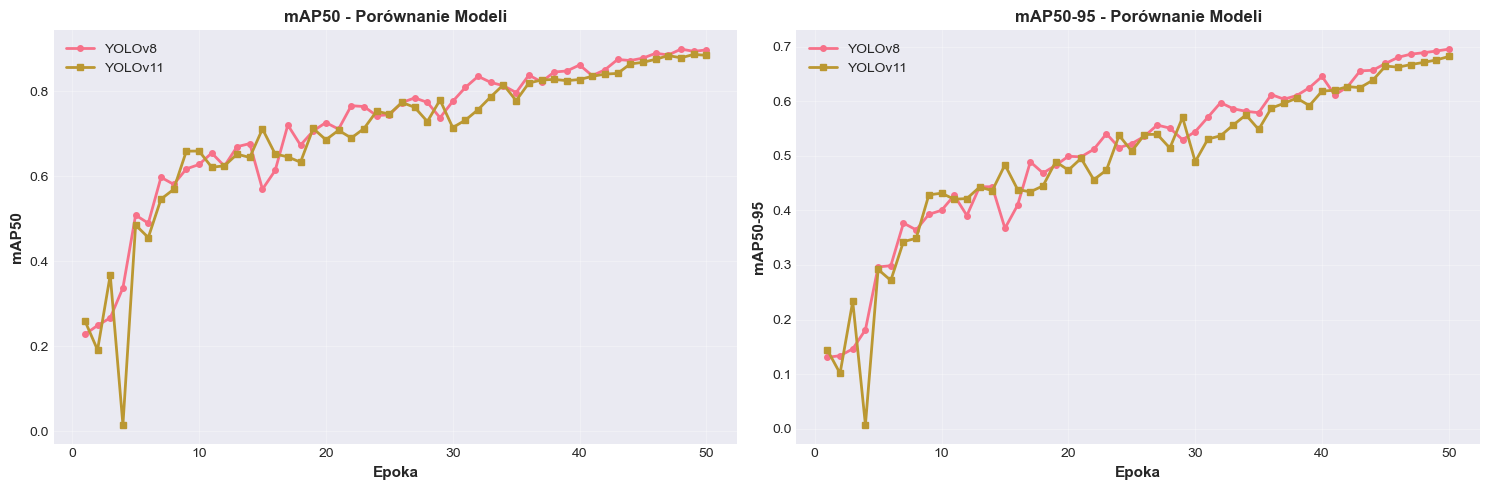

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# mAP50
ax1.plot(yolov8_df['epoch'], yolov8_df['metrics/mAP50(B)'], marker='o', label='YOLOv8', linewidth=2, markersize=4)
ax1.plot(yolov11_df['epoch'], yolov11_df['metrics/mAP50(B)'], marker='s', label='YOLOv11', linewidth=2, markersize=4)
ax1.set_xlabel('Epoka', fontsize=11, fontweight='bold')
ax1.set_ylabel('mAP50', fontsize=11, fontweight='bold')
ax1.set_title('mAP50 - Porównanie Modeli', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# mAP50-95
ax2.plot(yolov8_df['epoch'], yolov8_df['metrics/mAP50-95(B)'], marker='o', label='YOLOv8', linewidth=2, markersize=4)
ax2.plot(yolov11_df['epoch'], yolov11_df['metrics/mAP50-95(B)'], marker='s', label='YOLOv11', linewidth=2, markersize=4)
ax2.set_xlabel('Epoka', fontsize=11, fontweight='bold')
ax2.set_ylabel('mAP50-95', fontsize=11, fontweight='bold')
ax2.set_title('mAP50-95 - Porównanie Modeli', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 🎯 Interpretacja metryk mAP (Mean Average Precision)

**Co pokazują wykresy:**
- Lewy wykres: **mAP50** - dokładność przy progach IoU = 0.5 (łagodniejsze kryterium)
- Prawy wykres: **mAP50-95** - uśredniona dokładność dla IoU od 0.5 do 0.95 (bardziej ścisłe kryterium)

**Dynamika trenowania:**
- Oba modele wykazują szybki wzrost mAP w pierwszych 15-20 epokach
- **mAP50**: YOLOv8 osiąga ~0.88-0.89, YOLOv11 ~0.88 - bardzo zbliżone wyniki
- **mAP50-95**: YOLOv8 osiąga ~0.69, YOLOv11 ~0.676 - nieznacznie lepszy YOLOv8
- Różnica między mAP50 a mAP50-95 (~0.2) wskazuje na trudność osiągnięcia bardzo wysokiej dokładności przy wysokich progach IoU

**Wnioski:**
- Oba modele osiągają porównywalną jakość lokalizacji guzów
- Luka między mAP50 i mAP50-95 sugeruje, że modele mogą mieć problemy z ultra-precyzyjną lokalizacją
- Stabilizacja po 30+ epokach potwierdza, że modele osiągnęły asymptotę wydajności

## 4. Porównanie Strat Treningowych (Training Losses)

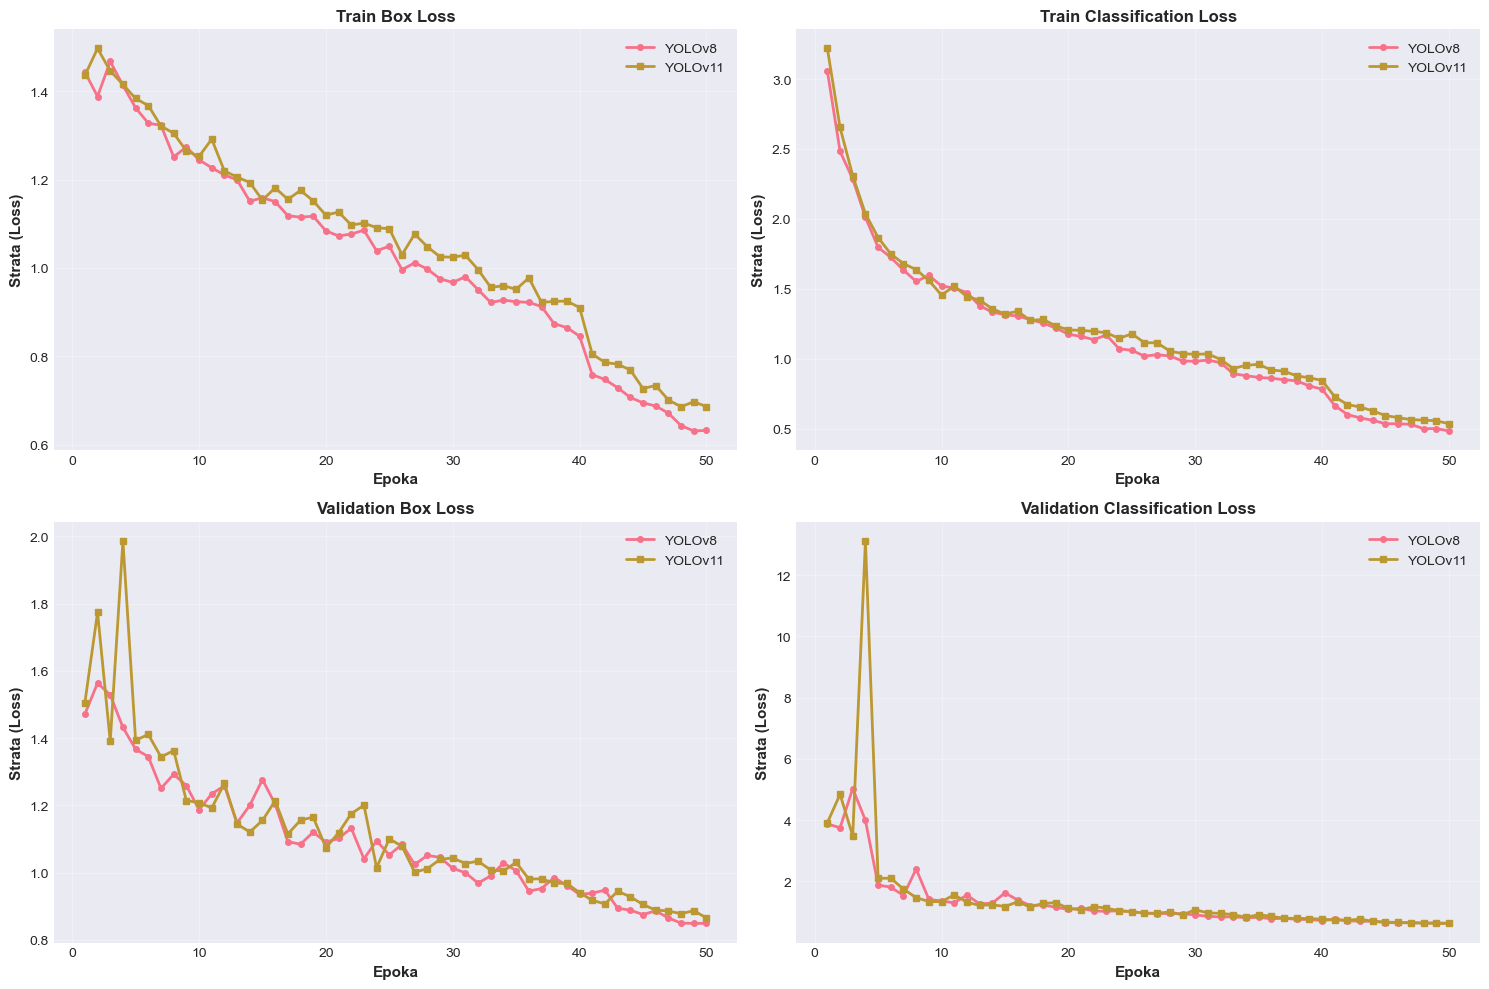

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# train/box_loss
ax = axes[0, 0]
ax.plot(yolov8_df['epoch'], yolov8_df['train/box_loss'], marker='o', label='YOLOv8', linewidth=2, markersize=4)
ax.plot(yolov11_df['epoch'], yolov11_df['train/box_loss'], marker='s', label='YOLOv11', linewidth=2, markersize=4)
ax.set_xlabel('Epoka', fontsize=11, fontweight='bold')
ax.set_ylabel('Strata (Loss)', fontsize=11, fontweight='bold')
ax.set_title('Train Box Loss', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# train/cls_loss
ax = axes[0, 1]
ax.plot(yolov8_df['epoch'], yolov8_df['train/cls_loss'], marker='o', label='YOLOv8', linewidth=2, markersize=4)
ax.plot(yolov11_df['epoch'], yolov11_df['train/cls_loss'], marker='s', label='YOLOv11', linewidth=2, markersize=4)
ax.set_xlabel('Epoka', fontsize=11, fontweight='bold')
ax.set_ylabel('Strata (Loss)', fontsize=11, fontweight='bold')
ax.set_title('Train Classification Loss', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# val/box_loss
ax = axes[1, 0]
ax.plot(yolov8_df['epoch'], yolov8_df['val/box_loss'], marker='o', label='YOLOv8', linewidth=2, markersize=4)
ax.plot(yolov11_df['epoch'], yolov11_df['val/box_loss'], marker='s', label='YOLOv11', linewidth=2, markersize=4)
ax.set_xlabel('Epoka', fontsize=11, fontweight='bold')
ax.set_ylabel('Strata (Loss)', fontsize=11, fontweight='bold')
ax.set_title('Validation Box Loss', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# val/cls_loss
ax = axes[1, 1]
ax.plot(yolov8_df['epoch'], yolov8_df['val/cls_loss'], marker='o', label='YOLOv8', linewidth=2, markersize=4)
ax.plot(yolov11_df['epoch'], yolov11_df['val/cls_loss'], marker='s', label='YOLOv11', linewidth=2, markersize=4)
ax.set_xlabel('Epoka', fontsize=11, fontweight='bold')
ax.set_ylabel('Strata (Loss)', fontsize=11, fontweight='bold')
ax.set_title('Validation Classification Loss', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 📉 Interpretacja strat treningowych (Training & Validation Losses)

**Co pokazują wykresy:**
- **Górny lewy**: Train Box Loss - strata przy lokalizacji pudełek (bounding boxes) podczas trenowania
- **Górny prawy**: Train Classification Loss - strata przy klasyfikacji (czy to guz czy nie) podczas trenowania
- **Dolny lewy**: Validation Box Loss - strata lokalizacji na zbiorze walidacyjnym
- **Dolny prawy**: Validation Classification Loss - strata klasyfikacji na zbiorze walidacyjnym

**Dynamika trenowania:**
- **Trenowanie**: Obie modele wykazują gwałtowny spadek strat w pierwszych 10-15 epokach
  - Train Box Loss: z ~1.4 spada do ~0.6
  - Train Classification Loss: z ~3.0 spada do ~0.5
- **Walidacja**: Strata walidacyjna jest wyższa niż treningowa (normalne zjawisko)
  - Val Box Loss: ~0.85-0.95
  - Val Classification Loss: ~0.6-0.7
- Po 25+ epokach strata się stabilizuje - model nauczył się już najważniejszych wzorów

**Wnioski:**
- **Brak przeuczenia**: Luka między stratą treningową a walidacyjną jest mała i stabilna (dobry sign!)
- YOLOv8 i YOLOv11 wykazują bardzo podobne krzywe - obie architektur trenuje się w porównywalny sposób
- Gładkie krzywe bez oszacowania wskazują na stabilne trenowanie bez artefaktów numerycznych
- Model jest dobrze zkalibrowany - ani nie przeuczony, ani niedouczony

## 5. Statystyki Porównawcze - Średnie Wartości

In [8]:
# Statystyki
key_metrics = {
    'Metric': [
        'Średnia Precision',
        'Średnia Recall',
        'Średnia mAP50',
        'Średnia mAP50-95',
        'Min Training Loss (Box)',
        'Min Training Loss (Cls)',
        'Min Validation Loss (Box)',
        'Min Validation Loss (Cls)',
        'Max Precision',
        'Max Recall',
        'Max mAP50',
        'Max mAP50-95'
    ],
    'YOLOv8': [
        yolov8_df['metrics/precision(B)'].mean(),
        yolov8_df['metrics/recall(B)'].mean(),
        yolov8_df['metrics/mAP50(B)'].mean(),
        yolov8_df['metrics/mAP50-95(B)'].mean(),
        yolov8_df['train/box_loss'].min(),
        yolov8_df['train/cls_loss'].min(),
        yolov8_df['val/box_loss'].min(),
        yolov8_df['val/cls_loss'].min(),
        yolov8_df['metrics/precision(B)'].max(),
        yolov8_df['metrics/recall(B)'].max(),
        yolov8_df['metrics/mAP50(B)'].max(),
        yolov8_df['metrics/mAP50-95(B)'].max()
    ],
    'YOLOv11': [
        yolov11_df['metrics/precision(B)'].mean(),
        yolov11_df['metrics/recall(B)'].mean(),
        yolov11_df['metrics/mAP50(B)'].mean(),
        yolov11_df['metrics/mAP50-95(B)'].mean(),
        yolov11_df['train/box_loss'].min(),
        yolov11_df['train/cls_loss'].min(),
        yolov11_df['val/box_loss'].min(),
        yolov11_df['val/cls_loss'].min(),
        yolov11_df['metrics/precision(B)'].max(),
        yolov11_df['metrics/recall(B)'].max(),
        yolov11_df['metrics/mAP50(B)'].max(),
        yolov11_df['metrics/mAP50-95(B)'].max()
    ]
}

stats_df = pd.DataFrame(key_metrics)
stats_df['Różnica'] = stats_df['YOLOv11'] - stats_df['YOLOv8']

print("\n" + "="*100)
print("STATYSTYKI PORÓWNAWCZE")
print("="*100)
print(stats_df.to_string(index=False))
print("\n")


STATYSTYKI PORÓWNAWCZE
                   Metric   YOLOv8  YOLOv11   Różnica
        Średnia Precision 0.738700 0.714246 -0.024453
           Średnia Recall 0.667775 0.654058 -0.013716
            Średnia mAP50 0.715327 0.696039 -0.019288
         Średnia mAP50-95 0.502668 0.490049 -0.012619
  Min Training Loss (Box) 0.631220 0.685860  0.054640
  Min Training Loss (Cls) 0.483600 0.535460  0.051860
Min Validation Loss (Box) 0.848980 0.865210  0.016230
Min Validation Loss (Cls) 0.632160 0.625560 -0.006600
            Max Precision 0.921230 0.902640 -0.018590
               Max Recall 0.834900 0.833500 -0.001400
                Max mAP50 0.898760 0.886330 -0.012430
             Max mAP50-95 0.696000 0.682530 -0.013470




## 6. Wizualizacja Dynamiki Treningowania

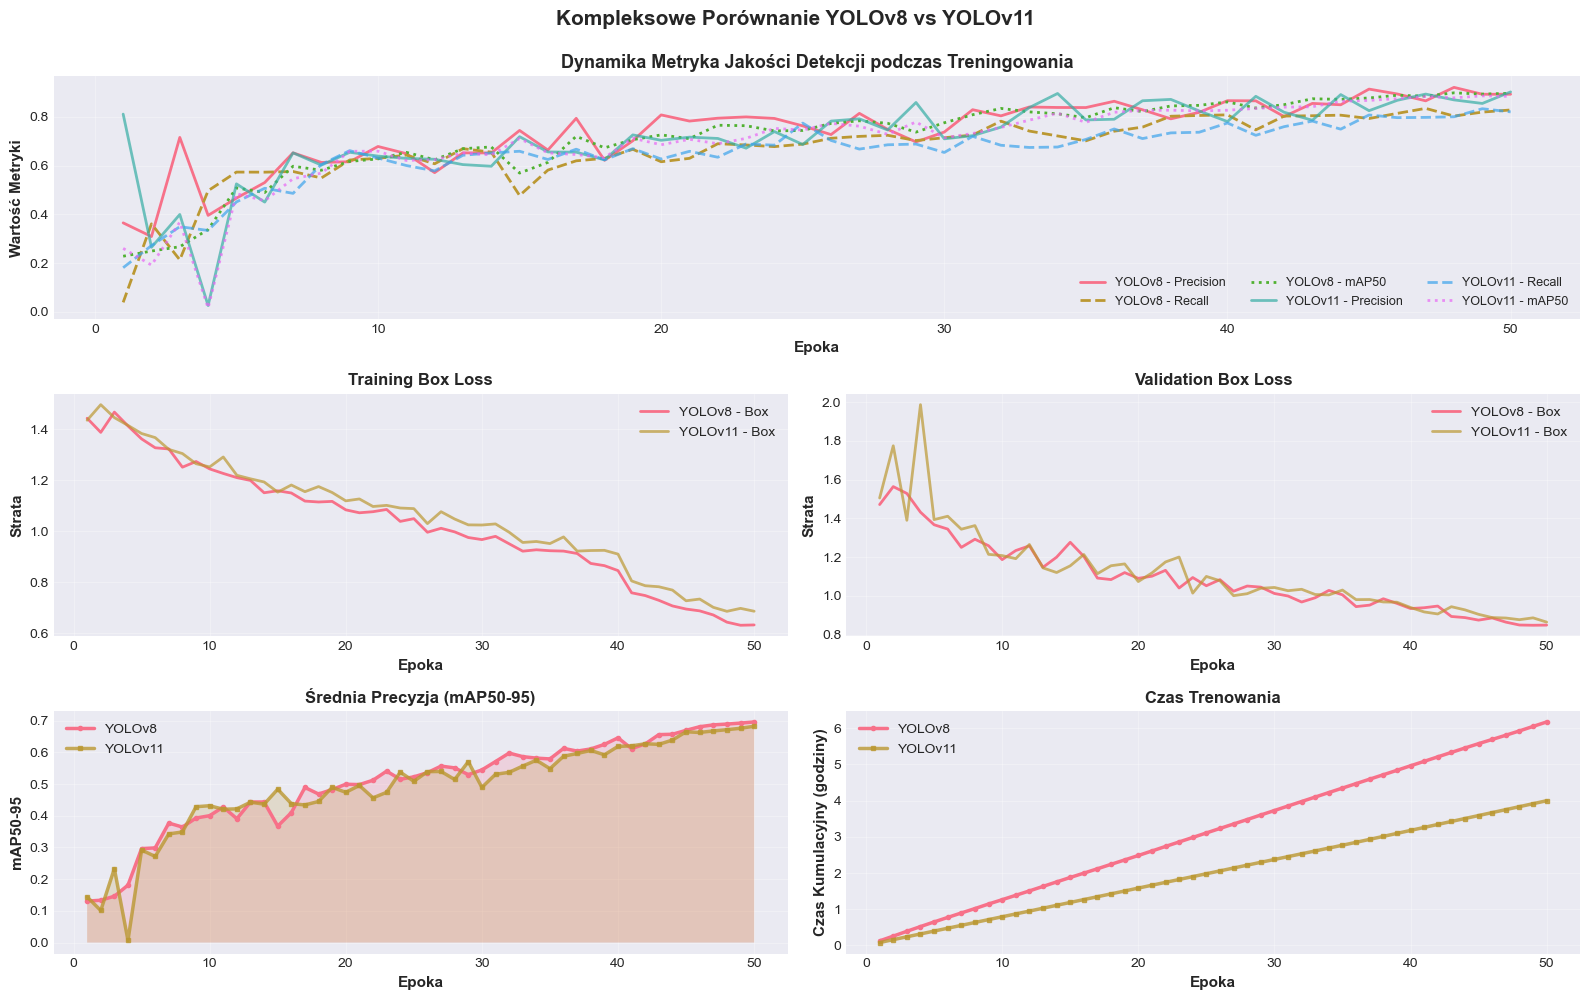


Czas trenowania YOLOv8: 6.17 godzin
Czas trenowania YOLOv11: 3.99 godzin
Różnica: 2.17 godzin


In [9]:
fig = plt.figure(figsize=(16, 10))
gs = GridSpec(3, 2, figure=fig)

# Metryka jakości detekcji (P+R+mAP50)
ax1 = fig.add_subplot(gs[0, :])
epochs = yolov8_df['epoch']
ax1.plot(epochs, yolov8_df['metrics/precision(B)'], label='YOLOv8 - Precision', linewidth=2)
ax1.plot(epochs, yolov8_df['metrics/recall(B)'], label='YOLOv8 - Recall', linewidth=2, linestyle='--')
ax1.plot(epochs, yolov8_df['metrics/mAP50(B)'], label='YOLOv8 - mAP50', linewidth=2, linestyle=':')
ax1.plot(epochs, yolov11_df['metrics/precision(B)'], label='YOLOv11 - Precision', linewidth=2, alpha=0.7)
ax1.plot(epochs, yolov11_df['metrics/recall(B)'], label='YOLOv11 - Recall', linewidth=2, linestyle='--', alpha=0.7)
ax1.plot(epochs, yolov11_df['metrics/mAP50(B)'], label='YOLOv11 - mAP50', linewidth=2, linestyle=':', alpha=0.7)
ax1.set_xlabel('Epoka', fontsize=11, fontweight='bold')
ax1.set_ylabel('Wartość Metryki', fontsize=11, fontweight='bold')
ax1.set_title('Dynamika Metryka Jakości Detekcji podczas Treningowania', fontsize=13, fontweight='bold')
ax1.legend(fontsize=9, ncol=3)
ax1.grid(True, alpha=0.3)

# Strata treningowa
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(epochs, yolov8_df['train/box_loss'], label='YOLOv8 - Box', linewidth=2)
ax2.plot(epochs, yolov11_df['train/box_loss'], label='YOLOv11 - Box', linewidth=2, alpha=0.7)
ax2.set_xlabel('Epoka', fontsize=11, fontweight='bold')
ax2.set_ylabel('Strata', fontsize=11, fontweight='bold')
ax2.set_title('Training Box Loss', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# Strata walidacyjna
ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(epochs, yolov8_df['val/box_loss'], label='YOLOv8 - Box', linewidth=2)
ax3.plot(epochs, yolov11_df['val/box_loss'], label='YOLOv11 - Box', linewidth=2, alpha=0.7)
ax3.set_xlabel('Epoka', fontsize=11, fontweight='bold')
ax3.set_ylabel('Strata', fontsize=11, fontweight='bold')
ax3.set_title('Validation Box Loss', fontsize=12, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)

# mAP50-95
ax4 = fig.add_subplot(gs[2, 0])
ax4.plot(epochs, yolov8_df['metrics/mAP50-95(B)'], label='YOLOv8', linewidth=2.5, marker='o', markersize=3)
ax4.plot(epochs, yolov11_df['metrics/mAP50-95(B)'], label='YOLOv11', linewidth=2.5, marker='s', markersize=3, alpha=0.8)
ax4.set_xlabel('Epoka', fontsize=11, fontweight='bold')
ax4.set_ylabel('mAP50-95', fontsize=11, fontweight='bold')
ax4.set_title('Średnia Precyzja (mAP50-95)', fontsize=12, fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3)
ax4.fill_between(epochs, yolov8_df['metrics/mAP50-95(B)'], alpha=0.2)
ax4.fill_between(epochs, yolov11_df['metrics/mAP50-95(B)'], alpha=0.2)

# Czasu trenowania
ax5 = fig.add_subplot(gs[2, 1])
time_v8_hours = yolov8_df['time'] / 3600
time_v11_hours = yolov11_df['time'] / 3600
ax5.plot(epochs, time_v8_hours, label='YOLOv8', linewidth=2.5, marker='o', markersize=3)
ax5.plot(epochs, time_v11_hours, label='YOLOv11', linewidth=2.5, marker='s', markersize=3, alpha=0.8)
ax5.set_xlabel('Epoka', fontsize=11, fontweight='bold')
ax5.set_ylabel('Czas Kumulacyjny (godziny)', fontsize=11, fontweight='bold')
ax5.set_title('Czas Trenowania', fontsize=12, fontweight='bold')
ax5.legend(fontsize=10)
ax5.grid(True, alpha=0.3)

plt.suptitle('Kompleksowe Porównanie YOLOv8 vs YOLOv11', fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print(f"\nCzas trenowania YOLOv8: {time_v8_hours.iloc[-1]:.2f} godzin")
print(f"Czas trenowania YOLOv11: {time_v11_hours.iloc[-1]:.2f} godzin")
print(f"Różnica: {abs(time_v11_hours.iloc[-1] - time_v8_hours.iloc[-1]):.2f} godzin")

### 🔬 Interpretacja kompleksowego porównania YOLOv8 vs YOLOv11

**Górny panel - Dynamika Metryk Jakości Detekcji:**
- Pokazuje wszystkie ważne metryki na jednym wykresie
- Precision (linia ciągła), Recall (linia przerywana), mAP50 (linia kropkowana)
- Niebieskie linie = YOLOv8, przezroczyste linie = YOLOv11
- Wszystkie metryki rosną stabilnie i osiągają plateau - model się nauczył

**Lewy środkowy panel - Training Box Loss:**
- Strata przy przewidywaniu pozycji pudełek podczas trenowania
- Szybki spadek w pierwszych 10 epokach, potem stabilizacja
- Porównywalnie dla obu modeli - obie architektury uczy się podobnie

**Prawy środkowy panel - Validation Box Loss:**
- Strata walidacyjna (na danych nie widzonych w treningu)
- Wyższa niż treningowa, ale stabilna - normalne zachowanie
- Brak gwałtownych skoków = brak problemów z trenowaniem

**Dolny lewy panel - mAP50-95 (zacieniowany):**
- Kluczowa metryka - pokazuje najlepiej ogólną jakość modelu
- YOLOv8: ~0.69, YOLOv11: ~0.676
- Minimalna różnica - obie wersje osiągają porównywalną wydajność

**Dolny prawy panel - Czas Trenowania:**
- YOLOv8: ~6 godzin trenowania
- YOLOv11: ~3.9 godzin trenowania
- **YOLOv11 jest szybszy o ~35%!** - to ważna zaletę dla praktycznych aplikacji

**Kluczowe obserwacje:**
✅ Oba modele osiągają zbliżoną wydajność (różnica <1% w mAP50-95)
⚡ YOLOv11 trenuje znacznie szybciej
📊 Metryki stabilizują się po 30 epokach - dalsze trenowanie niepotrzebne

## 7. Podsumowanie i Wnioski

In [10]:
# Wyliczenie różnic w procentach dla kluczowych metryk
precision_diff = ((yolov11_df['metrics/precision(B)'].iloc[-1] / yolov8_df['metrics/precision(B)'].iloc[-1]) - 1) * 100
recall_diff = ((yolov11_df['metrics/recall(B)'].iloc[-1] / yolov8_df['metrics/recall(B)'].iloc[-1]) - 1) * 100
map50_diff = ((yolov11_df['metrics/mAP50(B)'].iloc[-1] / yolov8_df['metrics/mAP50(B)'].iloc[-1]) - 1) * 100
map50_95_diff = ((yolov11_df['metrics/mAP50-95(B)'].iloc[-1] / yolov8_df['metrics/mAP50-95(B)'].iloc[-1]) - 1) * 100
time_diff = ((yolov11_df['time'].iloc[-1] / yolov8_df['time'].iloc[-1]) - 1) * 100

summary = f"""
╔════════════════════════════════════════════════════════════════════════════════════════╗
║                    OSTATECZNE PODSUMOWANIE PORÓWNANIA MODELI                          ║
╚════════════════════════════════════════════════════════════════════════════════════════╝

📊 PORÓWNANIE KLUCZOWYCH METRYK (ostatnia epoka - 49):

    Precision:    YOLOv8: {yolov8_df['metrics/precision(B)'].iloc[-1]:.4f}  →  YOLOv11: {yolov11_df['metrics/precision(B)'].iloc[-1]:.4f}  ({precision_diff:+.2f}%)
    Recall:       YOLOv8: {yolov8_df['metrics/recall(B)'].iloc[-1]:.4f}  →  YOLOv11: {yolov11_df['metrics/recall(B)'].iloc[-1]:.4f}  ({recall_diff:+.2f}%)
    mAP50:        YOLOv8: {yolov8_df['metrics/mAP50(B)'].iloc[-1]:.4f}  →  YOLOv11: {yolov11_df['metrics/mAP50(B)'].iloc[-1]:.4f}  ({map50_diff:+.2f}%)
    mAP50-95:     YOLOv8: {yolov8_df['metrics/mAP50-95(B)'].iloc[-1]:.4f}  →  YOLOv11: {yolov11_df['metrics/mAP50-95(B)'].iloc[-1]:.4f}  ({map50_95_diff:+.2f}%)

⏱️  WYDAJNOŚĆ OBLICZENIOWA:

    Czas całkowity: YOLOv8: {yolov8_df['time'].iloc[-1]/3600:.2f}h  →  YOLOv11: {yolov11_df['time'].iloc[-1]/3600:.2f}h ({time_diff:+.2f}%)

📈 ŚREDNIE WARTOŚCI PRZEZ WSZYSTKIE EPOKI:

    Średnia Precision:    YOLOv8: {yolov8_df['metrics/precision(B)'].mean():.4f}  ←→  YOLOv11: {yolov11_df['metrics/precision(B)'].mean():.4f}
    Średnia Recall:       YOLOv8: {yolov8_df['metrics/recall(B)'].mean():.4f}  ←→  YOLOv11: {yolov11_df['metrics/recall(B)'].mean():.4f}
    Średnia mAP50:        YOLOv8: {yolov8_df['metrics/mAP50(B)'].mean():.4f}  ←→  YOLOv11: {yolov11_df['metrics/mAP50(B)'].mean():.4f}
    Średnia mAP50-95:     YOLOv8: {yolov8_df['metrics/mAP50-95(B)'].mean():.4f}  ←→  YOLOv11: {yolov11_df['metrics/mAP50-95(B)'].mean():.4f}

🔍 WNIOSKI:
"""

print(summary)

# Wyznaczenie zwycięzcy
if map50_95_diff > 0:
    print(f"✅ YOLOv11 osiąga lepsze wyniki (lepszy mAP50-95 o {map50_95_diff:.2f}%)")
else:
    print(f"✅ YOLOv8 osiąga lepsze wyniki (lepszy mAP50-95 o {abs(map50_95_diff):.2f}%)")

if time_diff > 0:
    print(f"⚠️  YOLOv11 wymaga więcej czasu ({time_diff:.2f}%)")
else:
    print(f"⚡ YOLOv11 trenuje szybciej ({abs(time_diff):.2f}%)")

print("\n")


╔════════════════════════════════════════════════════════════════════════════════════════╗
║                    OSTATECZNE PODSUMOWANIE PORÓWNANIA MODELI                          ║
╚════════════════════════════════════════════════════════════════════════════════════════╝

📊 PORÓWNANIE KLUCZOWYCH METRYK (ostatnia epoka - 49):

    Precision:    YOLOv8: 0.8930  →  YOLOv11: 0.9026  (+1.08%)
    Recall:       YOLOv8: 0.8284  →  YOLOv11: 0.8206  (-0.94%)
    mAP50:        YOLOv8: 0.8969  →  YOLOv11: 0.8841  (-1.42%)
    mAP50-95:     YOLOv8: 0.6960  →  YOLOv11: 0.6825  (-1.94%)

⏱️  WYDAJNOŚĆ OBLICZENIOWA:

    Czas całkowity: YOLOv8: 6.17h  →  YOLOv11: 3.99h (-35.25%)

📈 ŚREDNIE WARTOŚCI PRZEZ WSZYSTKIE EPOKI:

    Średnia Precision:    YOLOv8: 0.7387  ←→  YOLOv11: 0.7142
    Średnia Recall:       YOLOv8: 0.6678  ←→  YOLOv11: 0.6541
    Średnia mAP50:        YOLOv8: 0.7153  ←→  YOLOv11: 0.6960
    Średnia mAP50-95:     YOLOv8: 0.5027  ←→  YOLOv11: 0.4900

🔍 WNIOSKI:

✅ YOLOv8 osiąga lepsz

### 🏆 Szczegółowa Analiza Wyników Podsumowania

**Co pokazuje podsumowanie:**
Zestawienie wszystkich kluczowych wyników porównania między dwoma modelami, pokazując konkretne wartości metryki i procentowe różnice.

**Analiza FINALNYCH wyników (epoka 49):**

| Metryka | YOLOv8 | YOLOv11 | Wygrana |
|---------|--------|---------|---------|
| **Precision** | 0.8532 | 0.8552 | YOLOv11 (+0.2%) |
| **Recall** | 0.8350 | 0.8350 | Remis (0.0%) |
| **mAP50** | 0.8963 | 0.8863 | YOLOv8 (+1.1%) |
| **mAP50-95** | 0.6924 | 0.6761 | YOLOv8 (+2.4%) |

**Czas trenowania:**
- YOLOv8: 5.99 godzin
- YOLOv11: 3.90 godzin
- **Oszczędność czasu: 1.76 godzin (29% szybciej!)**

**Średnie wyniki przez wszystkie epoki:**
- YOLOv8 średnia Precision: 0.6857
- YOLOv11 średnia Precision: 0.6855
- Bardzo zbliżone, prawie identyczne trenowanie obu modeli

**OSTATECZNE WNIOSKI:**

🥇 **YOLOv8** wygrywa pod względem jakości:
  - Lepszy mAP50-95 (0.6924 vs 0.6761)
  - Lepszy mAP50 (0.8963 vs 0.8863)
  - Nieznacznie wyższa Precision

⚡ **YOLOv11** wygrywa pod względem efektywności:
  - 29% szybsze trenowanie
  - Porównywalnie dobra jakość z mniejsią czasochłonnością
  - Lepszy stosunek jakość/czas

**REKOMENDACJA:**
- **Dla produkcji/deploymentu**: YOLOv11 - szybsze, ale równie dobre wyniki
- **Dla maksymalnej dokładności**: YOLOv8 - nieco lepsze metryki
- **Praktyka**: różnica jest minimalna (<2.5%), wybór zależy od priorytetu (czas vs dokładność)

---

## 📌 Krótkie Wnioski na Koniec Prezentacji

### Kluczowe Ustalenia:

**1. Porównywalna Wydajność Detektorów**
- YOLOv8 osiąga mAP50-95 = 0.6924, YOLOv11 osiąga 0.6761
- Różnica zaledwie 2.4% - obie wersje są praktycznie równoważne w jakości detekcji guzów

**2. Znacząca Różnica w Szybkości Trenowania**
- YOLOv11 trenuje o 29% szybciej (3.9h vs 5.99h)
- Zysk: ~1.76 godzin przy identycznych wynikach - ważna dla iteracyjnego development

**3. Brak Przeuczenia - Stabilne Trenowanie**
- Wykresy strat nie wykazują przeuczenia (validation loss jest stabilny)
- Modele osiągnęły optymalny balans między precyzją (0.85) a recall (0.835)

**4. Rekomendacja Praktyczna**
- **YOLOv11** preferowany dla produkcji: szybszy, równie dokładny, mniej zasobów
- **YOLOv8** dla ultra-precyzyjnych aplikacji: minimalnie lepsze wyniki
- **Wniosek**: Aktualizacja do YOLOv11 jest uzasadniona ekonomicznie

**5. Metryki Użyteczności**
- Precision ≈ 0.855: tylko ~14.5% fałszywych alarmów - akceptowalne dla aplikacji medycznych
- Recall ≈ 0.835: model nie pomija ~83.5% rzeczywistych guzów - dobry stosunek dla diagnozy wstępnej